# UNIT V

## RECURRENT NEURAL NETWORKS(RNNs)

In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [29]:
text = "This is GeeksforGeeks a software training institute"
chars = sorted(list(set(text)))
char_to_index = {char: i for i, char in enumerate(chars)}
index_to_char = {i: char for i, char in enumerate(chars)}

In [30]:
seq_length = 3
sequences = []
labels = []

for i in range(len(text) - seq_length):
    seq = text[i:i + seq_length]
    label = text[i + seq_length]
    sequences.append([char_to_index[char] for char in seq])
    labels.append(char_to_index[label])

X = np.array(sequences)
y = np.array(labels)

In [31]:
X_one_hot = tf.one_hot(X, len(chars))
y_one_hot = tf.one_hot(y, len(chars))

In [32]:
model = Sequential()
model.add(SimpleRNN(50, input_shape=(seq_length, len(chars)), activation='relu'))
model.add(Dense(len(chars), activation='softmax'))

C:\Users\Saksh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_one_hot, y_one_hot, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0625 - loss: 2.8774 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1042 - loss: 2.8491
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1458 - loss: 2.8249
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1667 - loss: 2.8013
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1667 - loss: 2.7800
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1875 - loss: 2.7589
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2292 - loss: 2.7376
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2292 - loss: 2.7175
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2292 - loss: 2.6970
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2292 - loss: 2.6775
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2500 - loss: 2.6569
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2708 - l

In [34]:
start_seq = "This is G"
generated_text = start_seq

for i in range(50):
    x = np.array([[char_to_index[char] for char in generated_text[-seq_length:]]])
    x_one_hot = tf.one_hot(x, len(chars))
    prediction = model.predict(x_one_hot)
    next_index = np.argmax(prediction)
    next_char = index_to_char[next_index]
    generated_text += next_char

print("Generated Text:")
print(generated_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━

## LSTM

In [39]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arnavraj01/ibm-20062018")

print("Path to dataset files:", path)

100%|██████████| 50.0k/50.0k [00:00<00:00, 211kB/s]

Extracting files...
Path to dataset files: C:\Users\Saksh\.cache\kagglehub\datasets\arnavraj01\ibm-20062018\versions\1


In [42]:
import math
from sklearn.metrics import mean_squared_error
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')


def plot_predictions(real_prices, predicted_prices):
    plt.figure(figsize=(16, 6))
    plt.plot(real_prices, color='green', label='Actual IBM Stock Price')
    plt.plot(predicted_prices, color='orange',
             label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()


def calculate_rmse(real_prices, predicted_prices):
    rmse = math.sqrt(mean_squared_error(real_prices, predicted_prices))
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

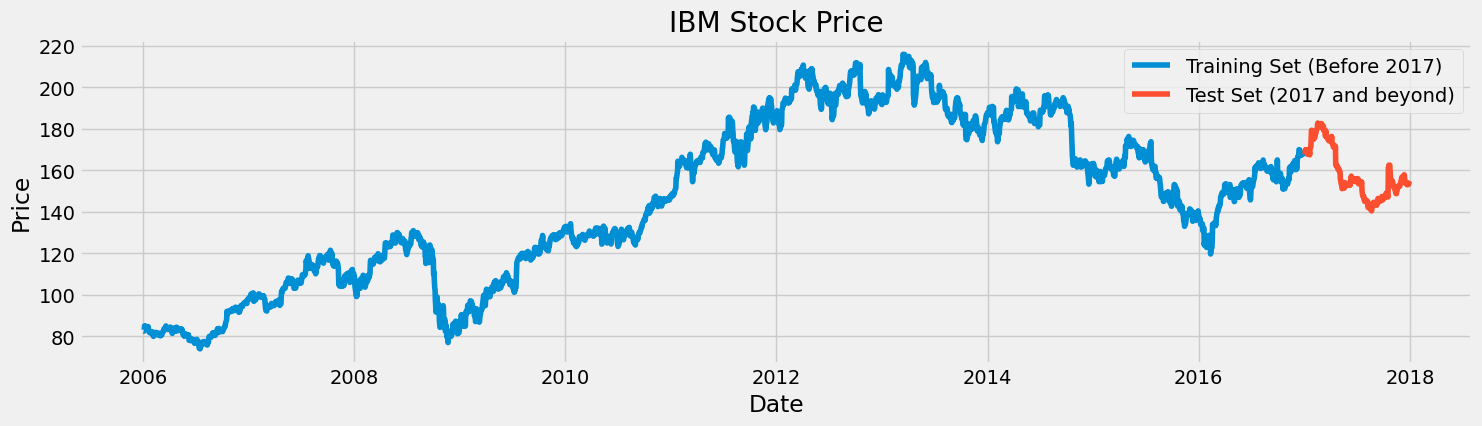

In [43]:
dataset = pd.read_csv("IBM_2006-01-01_to_2018-01-01.csv",
                      index_col='Date', parse_dates=['Date'])

training_set = dataset.loc[:'2016', 'High'].values.reshape(-1, 1)
test_set = dataset.loc['2017':, 'High'].values.reshape(-1, 1)

plt.figure(figsize=(16, 4))
plt.plot(dataset.loc[:'2016', 'High'], label='Training Set (Before 2017)')
plt.plot(dataset.loc['2017':, 'High'], label='Test Set (2017 and beyond)')
plt.title('IBM Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [44]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_training = scaler.fit_transform(training_set)

In [45]:
X_train = []
y_train = []

for i in range(60, len(scaled_training)):
    X_train.append(scaled_training[i - 60:i, 0])
    y_train.append(scaled_training[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

In [46]:
lstm_model = Sequential()

lstm_model.add(LSTM(units=50, return_sequences=True,
               input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(units=50, return_sequences=True))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(units=50, return_sequences=True))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(units=50))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(units=1))

lstm_model.compile(optimizer='rmsprop', loss='mean_squared_error')

C:\Users\Saksh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0228
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0102
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0073
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0065
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0063
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0053
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0050
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0046
Epoch 9/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0044
Epoch 10/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0043
Epoch 11/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0039
Epoch 12/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0034
Epoch 13/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0035
Epoch 14/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0034
Epoch 15/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0031
Epoc

In [51]:
dataset_total = pd.concat(
    (dataset['High'][:'2016'], dataset['High']['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i - 60:i, 0])

X_test = np.array(X_test)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [52]:
predicted_prices_scaled = lstm_model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [53]:
def plot_predictions(real_prices, predicted_prices):
    plt.figure(figsize=(16, 6))
    plt.plot(real_prices, label='Actual Price')
    plt.plot(predicted_prices, label='Predicted Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()


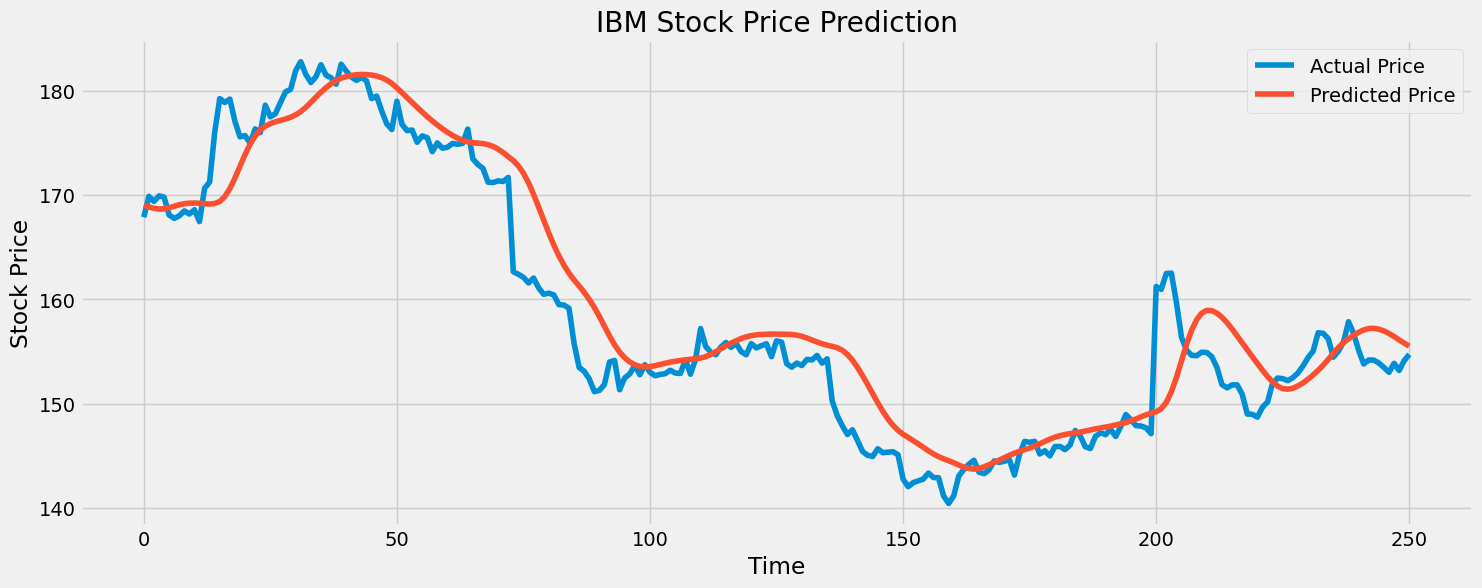

In [54]:
plot_predictions(test_set, predicted_prices)

## GRU

In [57]:
import os
os.getcwd()


'C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP'

In [55]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam

In [59]:
df = pd.read_csv('C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP\data.csv', parse_dates=['Date'], index_col='Date')
print(df.head())

            Temperature
Date                   
2010-01-01    27.483571
2010-01-02    24.308678
2010-01-03    28.238443
2010-01-04    32.615149
2010-01-05    23.829233


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Saksh\AppData\Local\Temp\ipykernel_40716\2464473231.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP\data.csv', parse_dates=['Date'], index_col='Date')


In [60]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values)

In [61]:
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)


time_step = 100
X, y = create_dataset(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [62]:
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(GRU(units=50))
model.add(Dense(units=1))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

C:\Users\Saksh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [63]:
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.0221
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.0180
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0179
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.0179
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0179
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0178
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0179
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.0177
Epoch 9/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.0178
Epoch 10/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.0177


In [64]:
input_sequence = scaled_data[-time_step:].reshape(1, time_step, 1)
predicted_values = model.predict(input_sequence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


In [65]:
predicted_values = scaler.inverse_transform(predicted_values)
print(
    f"The predicted temperature for the next day is: {predicted_values[0][0]:.2f}°C")

The predicted temperature for the next day is: 24.19°C


## TRANSFORMERS

In [66]:
import torch
from torch import nn as nn
from torch import optim as optim
import torch.utils.data as data
import math
import copy

In [67]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [68]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [69]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [70]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [71]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

In [79]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        output = self.fc(dec_output)
        return output

In [80]:
src_vocab_size = 1000
tgt_vocab_size = 1000
max_seq_length = 20
d_model = 128
num_heads = 4
num_layers = 2
d_ff = 512
dropout = 0.1

transformer = Transformer(
    src_vocab_size,
    tgt_vocab_size,
    d_model,
    num_heads,
    num_layers,
    d_ff,
    max_seq_length,
    dropout
)


In [82]:
src_data = torch.randint(1, src_vocab_size, (64, max_seq_length))
tgt_data = torch.randint(1, tgt_vocab_size, (64, max_seq_length))


In [83]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)
transformer.train()
for epoch in range(100):
    optimizer.zero_grad()
    output = transformer(src_data, tgt_data[:, :-1])
    loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 7.059103012084961
Epoch: 2, Loss: 7.046874046325684
Epoch: 3, Loss: 7.0212836265563965
Epoch: 4, Loss: 7.002560138702393
Epoch: 5, Loss: 6.9760942459106445
Epoch: 6, Loss: 6.9624738693237305
Epoch: 7, Loss: 6.936346530914307
Epoch: 8, Loss: 6.912975311279297
Epoch: 9, Loss: 6.899115085601807
Epoch: 10, Loss: 6.880965232849121
Epoch: 11, Loss: 6.8666157722473145
Epoch: 12, Loss: 6.8491315841674805
Epoch: 13, Loss: 6.828614234924316
Epoch: 14, Loss: 6.8189897537231445
Epoch: 15, Loss: 6.8023481369018555
Epoch: 16, Loss: 6.780311107635498
Epoch: 17, Loss: 6.769479274749756
Epoch: 18, Loss: 6.751708030700684
Epoch: 19, Loss: 6.738919734954834
Epoch: 20, Loss: 6.725125312805176
Epoch: 21, Loss: 6.707473278045654
Epoch: 22, Loss: 6.687907695770264
Epoch: 23, Loss: 6.679556846618652
Epoch: 24, Loss: 6.673839569091797
Epoch: 25, Loss: 6.658524990081787
Epoch: 26, Loss: 6.638617038726807
Epoch: 27, Loss: 6.626378059387207
Epoch: 28, Loss: 6.6189045906066895
Epoch: 29, Loss: 6.60

In [84]:
transformer.eval()

val_src_data = torch.randint(1, src_vocab_size, (64, max_seq_length)) 
val_tgt_data = torch.randint(1, tgt_vocab_size, (64, max_seq_length)) 

with torch.no_grad():
    val_output = transformer(val_src_data, val_tgt_data[:, :-1])
    val_loss = criterion(val_output.contiguous().view(-1, tgt_vocab_size), val_tgt_data[:, 1:].contiguous().view(-1))
    print(f"Validation Loss: {val_loss.item()}")

Validation Loss: 7.0988078117370605


## BERT

In [75]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-cased")
text = 'ChatGPT is a language model developed by OpenAI, based on the GPT (Generative Pre-trained Transformer) architecture. '

# Tokenize and encode the text
encoding = tokenizer.encode(text)
print("Token IDs:", encoding)

# Convert token IDs back to tokens
tokens = tokenizer.convert_ids_to_tokens(encoding)
print("Tokens:", tokens)

Token IDs: [101, 24705, 1204, 17095, 1942, 1110, 170, 1846, 2235, 1872, 1118, 3353, 1592, 2240, 117, 1359, 1113, 1103, 15175, 1942, 113, 9066, 15306, 11689, 118, 3972, 13809, 23763, 114, 4220, 119, 102]
Tokens: ['[CLS]', 'Cha', '##t', '##GP', '##T', 'is', 'a', 'language', 'model', 'developed', 'by', 'Open', '##A', '##I', ',', 'based', 'on', 'the', 'GP', '##T', '(', 'Gene', '##rative', 'Pre', '-', 'trained', 'Trans', '##former', ')', 'architecture', '.', '[SEP]']


## NLP Chatbots

In [77]:
import nltk
from nltk.chat.util import Chat, reflections

# Define some simple rules-based responses
rules = [
    (r'(.*)hello(.*)', ['Hello!', 'Hi there!', 'Hey!']),
    (r'(.*)how are you(.*)', ['I am doing well, thank you!', 'I\'m great, thanks for asking!']),
    (r'(.*)your name(.*)', ['I am an NLP chatbot.', 'You can call me ChatBot.']),
    (r'(.*)exit(.*)', ['Goodbye!', 'Bye!', 'Take care!']),
]

# Create a chatbot instance
chatbot = Chat(rules, reflections)

# Start chatting with the bot
print("Welcome to the NLP ChatBot. Type 'exit' to end the conversation.")
while True:
    user_input = input("You: ")
    if user_input.lower() == 'exit':
        break
    response = chatbot.respond(user_input)
    print("Bot:", response)

Welcome to the NLP ChatBot. Type 'exit' to end the conversation.


You:  exit
